Importing Libraries



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
sns.set(style="whitegrid")

Uploading File

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Decio_Sleep,Screen Time, Stress Dataset.csv to Decio_Sleep,Screen Time, Stress Dataset.csv


In [5]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Decio_Sleep,Screen Time, Stress Dataset.csv']))
df

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,79,46,Female,Designer,4.43,119,8.54,6.00,7.39,0,87,89,8.79
79,80,32,Female,Researcher,3.59,57,5.04,7.20,5.67,4,50,276,5.69
80,81,18,Female,Student,9.25,91,6.83,4.13,10.00,0,112,166,10.00
81,82,42,Male,Software Engineer,2.16,45,6.61,7.16,4.26,1,82,276,3.81


In [45]:
df.drop(columns=['user_id','age','phone_usage_before_sleep_minutes','sleep_duration_hours','sleep_quality_score','caffeine_intake_cups','physical_activity_minutes','notifications_received_per_day','mental_fatigue_score'])
print(df)

,occupation,daily_screen_time_hours,stress_level
0,Designer,3.26,3.49
1,Teacher,1.85,3.01
2,Designer,3.04,5.03
3,Software Engineer,9.00,10.00
4,Teacher,3.52,6.71
...,...,...,...
78,Designer,4.43,7.39
79,Researcher,3.59,5.67
80,Student,9.25,10.00
81,Software Engineer,2.16,4.26


What variable are you trying to predict?

- I'm trying to predict how screentime negatively affects their stress level

Why is it meaningful or important?

- As one ages, it is important to maintain a balance lifestyle between our phones and rest.


What variables might influence it, and why?

- Daily screen time hours and stress level could be the most important influences as it affects how one functions.


In [36]:
# Descriptive Statistics
print("Descriptive Statistics:\n", df[['daily_screen_time_hours','stress_level']].describe())

# Median
print("\nMedian: \n", df[['daily_screen_time_hours','stress_level']].median())

# Mean Absolute Deviation
mad_value = df[['daily_screen_time_hours','stress_level']].apply(lambda x: np.mean(np.abs(x - x.mean())))
print("\nMean Absolute Deviation: \n", mad_value)

# Skewness and Kurtosis
print("\nSkewness: \n", df[['daily_screen_time_hours','stress_level']].skew())
print("\nKurtosis: \n", df[['daily_screen_time_hours','stress_level']].kurt())


Descriptive Statistics:
        daily_screen_time_hours  stress_level
count                83.000000     83.000000
mean                  4.659277      6.220361
std                   2.686347      2.887613
min                   1.010000      1.000000
25%                   2.335000      4.060000
50%                   3.990000      6.430000
75%                   6.760000      9.150000
max                   9.960000     10.000000

Median: 
 daily_screen_time_hours    3.99
stress_level               6.43
dtype: float64

Mean Absolute Deviation: 
 daily_screen_time_hours    2.318493
stress_level               2.509505
dtype: float64

Skewness: 
 daily_screen_time_hours    0.489963
stress_level              -0.134428
dtype: float64

Kurtosis: 
 daily_screen_time_hours   -1.007484
stress_level              -1.208554
dtype: float64


Regression Analysis & Scatter Plot

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

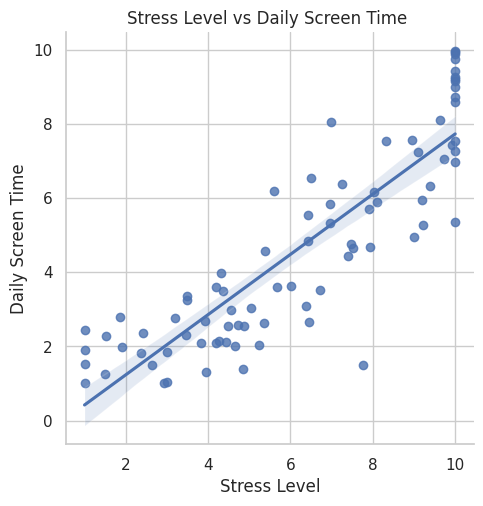

In [41]:
# Regression Plot: Age vs Daily Screentime Hours
sns.lmplot(x='stress_level', y='daily_screen_time_hours', data=df)
plt.title("Stress Level vs Daily Screen Time ")
plt.xlabel("Stress Level")
plt.ylabel("Daily Screen Time")
plt.show()


OLS Regression Analysis

In [40]:
# Identifying Independent Variable
X = df[['stress_level']]
X = sm.add_constant(X)

# Identifying Dependent Variables
y = df['daily_screen_time_hours']

# Printing OLS Model
model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     daily_screen_time_hours   R-squared:                       0.761
Model:                                 OLS   Adj. R-squared:                  0.758
Method:                      Least Squares   F-statistic:                     257.4
Date:                     Thu, 12 Mar 2026   Prob (F-statistic):           7.14e-27
Time:                             07:30:51   Log-Likelihood:                -139.95
No. Observations:                       83   AIC:                             283.9
Df Residuals:                           81   BIC:                             288.7
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

Your predictive goal and dataset summary
- I was predicting that there is a negative effect on how high screentimes affect one's stress level. Based on OLS Regression Analysis and Scatter Plot presented. It shows that stress levels goes higher as our screentime increases.


Data cleaning steps and feature engineering

- Before uploading the file, I firstly lessen the number of rows to keep it small and accessible. From 400 records, I intentionally made it. I also removed unncessecary columns for the analysis.


Full interpretation of all listed metrics
- The data shows that a person's stress levels goes up can be due to one's amount of screen time everyday.


Summary of improvements and updated model performance
- I intertwined the X data to Y data and vice-versa to make the study more accurate, since even if the R-squared is high, there are still values that doesn't enter the standards for other analysis such as confidence interval, coefficient, and T-Values.
